# Example of the AiTLAS toolbox for multiclass classification using Galileo

## Define the FAIREOSchema for dataset import

In [1]:
from marshmallow import fields

from aitlas.base.schemas import BaseDatasetSchema


class FAIREOSchema(BaseDatasetSchema):
    """
    Schema for FAIREO datasets.
    """

    csv_file = fields.String(
        load_default=None,
        metadata={"description": "CSV file on disk", "example": "./data/train.csv"},
    )
    data_dir = fields.String(
        load_default="/",
        metadata={"description": "Dataset path on disk", "example": "./data/CESBIO/"},
    )
    selection = fields.String(
        load_default="rgb",
        metadata={"description": "Read RGB channels or 13 channels", "example": "all/rgb"},
    )

class BrazilDAMSchema(BaseDatasetSchema):
    """
    Schema for configuring the BrazilDAM dataset.
    """

    data_dir = fields.String(
        load_default="/", metadata={"description": "Dataset path on disk", "example": "./data/CESBIO/"}
    )
    csv_file = fields.String(
        load_default=None, metadata={"description": "CSV file on disk", "example": "./data/train.csv"}
    )
    imagery = fields.String(
        load_default="sentinel",
        metadata={"description": "Select which imagery to use: 'sentinel', 'landsat' or 'sentinel and landsat'", "example": "sentinel"},
    )
    selection = fields.String(
        load_default="rgb",
        metadata={"description": "Read RGB channels, all channels or specific ones", "example": "all/rgb/bands"},
    )
    bands_s2 = fields.List(
        fields.String(),
        load_default=None,
        metadata={"description": "Select which S2 bands to use with a list of band names", "example": ["B01", "B02", "B03"]},
    )
    bands_l8 = fields.List(
        fields.String(),
        load_default=None,
        metadata={"description": "Select which L8 bands to use with a list of band names", "example": ["B01", "B02", "B03"]},
    )


/home/dragik/tadej/aitlas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dragik/tadej/aitlas/aitlas/models/AnySat/utils/irpe.py:18: UserWarning: 
  warnings.warn(
/home/dragik/tadej/aitlas/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Define the BrazilDAM dataset
BrazilDAM is a multi sensor and multitemporal dataset that consists of multispectral images 
of ore tailings dams throughout Brazil. Images are from Sentinel-2 and Landsat 8 satellites.

In [4]:
import numpy as np
import os
import pandas as pd
import csv
import matplotlib.pyplot as plt

from aitlas.base import BaseDataset
from aitlas.base.schemas import BaseDatasetSchema
from aitlas.utils import image_loader


LABELS = ["nao_barragem", "barragem"]


class BrazilDAMDataset(BaseDataset):
    url = "https://drive.google.com/drive/folders/1v1F4faAD8zCm_vocGxILiIUncaRz1pZB"
    labels = LABELS
    name = "BrazilDAM dataset"
    schema = BrazilDAMSchema

    def __init__(self, config):
        # now call the constructor to validate the schema and load the data
        super().__init__(config)
        # load the data
        self.data_dir = self.config.data_dir
        self.csv_file = self.config.csv_file
        self.imagery = self.config.imagery
        self.selection = self.config.selection
        self.bands_s2 = self.config.bands_s2
        self.bands_l8 = self.config.bands_l8
        self.data = self.load_dataset()

    def __getitem__(self, index):
        """
        :param index: Index
        :type index: int
        :return: tuple where target is index of the target class.
        :rtype: tuple (image, target)

        """

        # consider only Sentinel-2
        if self.imagery == "sentinel":
            img = image_loader(self.data[index][0][0])
            satellite = self.data[index][1]
            if self.selection == "rgb":
                img = img[:, :, 1:4]
            elif self.selection == "all":
                img = img
            elif self.selection == "bands":
                if self.bands_s2 == None:
                    print("The config must contain a bands_s2 field with a list of chosen bands")
                idx = []
                s2_bands = [
                    "B01",
                    "B02",
                    "B03",
                    "B04",
                    "B05",
                    "B06",
                    "B07",
                    "B08",
                    "B8A",
                    "B09",
                    "B10",
                    "B11",
                    "B12",
                ]
                for b in self.bands_s2:
                    if b not in s2_bands:
                        print(
                            "The bands must be valid Sentinel-2 bands, i.e. one of B01, B02, B03, B04, B05, B06, B07, B08, B8A, B09, B10, B11, B12"
                        )
                        break
                    else:
                        idx.append(s2_bands.index(b))
                img = img[:, :, idx]
            # normalize the image
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # consider only Landsat 8
        elif self.imagery == "landsat":
            img = image_loader(self.data[index][0][0])
            satellite = self.data[index][1]
            if self.selection == "rgb":
                img = img[:, :, 1:4]
            elif self.selection == "all":
                img = img
            elif self.selection == "bands":
                if self.bands_l8 == None:
                    print("The config must contain a bands_l8 field with a list of chosen bands")
                idx = []
                l8_bands = [
                    "B01",
                    "B02",
                    "B03",
                    "B04",
                    "B05",
                    "B06",
                    "B07",
                    "B08",
                    "B09",
                    "B10",
                    "B11",
                ]
                for b in self.bands_l8:
                    if b not in l8_bands:
                        print(
                            "The bands must be valid Landsat 8 bands, i.e. one of B01, B02, B03, B04, B05, B06, B07, B08, B09, B10, B11"
                        )
                        break
                    else:
                        idx.append(l8_bands.index(b))
                img = img[:, :, idx]
            # normalize the image
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # consider unpaired Sentinel-2 and Landsat 8
        elif self.imagery == "sentinel and landsat unpaired":
            img = image_loader(self.data[index][0][0])
            satellite = self.data[index][1]
            if satellite == "sentinel":
                if self.selection == "rgb":
                    img = img[:, :, 1:4]
                elif self.selection == "all":
                    img = img
                elif self.selection == "bands":
                    if self.bands_s2 == None:
                        print(
                            "The config must contain a bands_s2 field with a list of chosen bands"
                        )
                    idx = []
                    s2_bands = [
                        "B01",
                        "B02",
                        "B03",
                        "B04",
                        "B05",
                        "B06",
                        "B07",
                        "B08",
                        "B8A",
                        "B09",
                        "B10",
                        "B11",
                        "B12",
                    ]
                    for b in self.bands_s2:
                        if b not in s2_bands:
                            print(
                                "The bands must be valid Sentinel-2 bands, i.e. one of B01, B02, B03, B04, B05, B06, B07, B08, B8A, B09, B10, B11, B12"
                            )
                            break
                        else:
                            idx.append(s2_bands.index(b))
                    img = img[:, :, idx]

            elif satellite == "landsat":
                if self.selection == "rgb":
                    img = img[:, :, 1:4]
                elif self.selection == "all":
                    img = img
                elif self.selection == "bands":
                    if self.bands_l8 == None:
                        print(
                            "The config must contain a bands_l8 field with a list of chosen bands"
                        )
                    idx = []
                    l8_bands = [
                        "B01",
                        "B02",
                        "B03",
                        "B04",
                        "B05",
                        "B06",
                        "B07",
                        "B08",
                        "B09",
                        "B10",
                        "B11",
                    ]
                    for b in self.bands_l8:
                        if b not in l8_bands:
                            print(
                                "The bands must be valid Landsat 8 bands, i.e. one of B01, B02, B03, B04, B05, B06, B07, B08, B09, B10, B11"
                            )
                            break
                        else:
                            idx.append(l8_bands.index(b))
                    img = img[:, :, idx]

            # normalize the image
            img_min, img_max = img.min(), img.max()
            img = (img - img_min) / (img_max - img_min + 1e-8)

        # consider S2 and L8 pairs where available
        if self.imagery == "sentinel and landsat paired":
            s2_img = image_loader(os.path.join(self.data_dir, "sentinel", self.data[index][0][0]))
            if self.selection == "rgb":
                s2_img = s2_img[:, :, 1:4]
            elif self.selection == "all":
                s2_img = s2_img
            elif self.selection == "bands":
                if self.bands_s2 == None:
                    print("The config must contain a bands_s2 field with a list of chosen bands")
                idx = []
                s2_bands = [
                    "B01",
                    "B02",
                    "B03",
                    "B04",
                    "B05",
                    "B06",
                    "B07",
                    "B08",
                    "B8A",
                    "B09",
                    "B10",
                    "B11",
                    "B12",
                ]
                for b in self.bands_s2:
                    if b not in s2_bands:
                        print(
                            "The bands must be valid Sentinel-2 bands, i.e. one of B01, B02, B03, B04, B05, B06, B07, B08, B8A, B09, B10, B11, B12"
                        )
                        break
                    else:
                        idx.append(s2_bands.index(b))
                s2_img = s2_img[:, :, idx]
            s2_img = (s2_img - s2_img.min()) / (
                s2_img.max() - s2_img.min() + 1e-8
            )  # normalize image

            l8_img = image_loader(os.path.join(self.data_dir, "landsat", self.data[index][0][0]))
            if self.selection == "rgb":
                l8_img = l8_img[:, :, 1:4]
            elif self.selection == "all":
                l8_img = l8_img
            elif self.selection == "bands":
                if self.bands_l8 == None:
                    print("The config must contain a bands_l8 field with a list of chosen bands")
                idx = []
                l8_bands = [
                    "B01",
                    "B02",
                    "B03",
                    "B04",
                    "B05",
                    "B06",
                    "B07",
                    "B08",
                    "B09",
                    "B10",
                    "B11",
                ]
                for b in self.bands_l8:
                    if b not in l8_bands:
                        print(
                            "The bands must be valid Landsat 8 bands, i.e. one of B01, B02, B03, B04, B05, B06, B07, B08, B09, B10, B11"
                        )
                        break
                    else:
                        idx.append(l8_bands.index(b))
                l8_img = l8_img[:, :, idx]
            l8_img = (l8_img - l8_img.min()) / (l8_img.max() - l8_img.min() + 1e-8)

            img = np.dstack((s2_img, l8_img))

        # apply transformations
        if self.transform:
            img = self.transform(img)
        target = self.data[index][0][1]
        if self.target_transform:
            target = self.target_transform(target)
        return img, target

    def load_dataset(self):
        data = []
        if self.csv_file:  # csv file created by BVLabs provide a 60/20/20 split with a stratification based on satellite, class and year
            with open(self.csv_file, "r") as f:
                csv_reader = csv.reader(f)
                raw_data = list(csv_reader)

                for row in raw_data[1:]:
                    file_name = row[0]
                    satellite = row[1]
                    label = row[2]
                    year = row[3]

                    item = (
                        os.path.join(self.data_dir, satellite, year, file_name),
                        self.labels.index(label),
                    )

                    if self.imagery == "sentinel":
                        if satellite == "sentinel":
                            data.append((item, satellite))
                    elif self.imagery == "landsat":
                        if satellite == "landsat":
                            data.append((item, satellite))
                    elif self.imagery == "sentinel and landsat unpaired":
                        data.append((item, satellite))
                    elif self.imagery == "sentinel and landsat paired":
                        if (
                            satellite == "sentinel"
                        ):  # both S2 and L8 have the same file_name if belonging to the same pair
                            if os.path.exists(
                                os.path.join(self.data_dir, "landsat", year, file_name)
                            ):  # not all S2 have a corresponding L8
                                item = (
                                    os.path.join(year, file_name),
                                    self.labels.index(label),
                                )
                                data.append((item, satellite))

        if not self.labels:
            raise ValueError("You need to provide the list of labels for the dataset")

        return data

    def __len__(self):
        return len(self.data)

    def get_labels(self):
        return self.labels

    def show_samples(self):
        file_names = [os.path.basename(item[0][0]) for item in self.data]
        labels = [self.labels[item[0][1]] for item in self.data]
        df = pd.DataFrame({"File_name": file_names, "Label": labels})
        return df.head(20)

    def data_distribution_table(self):
        df = pd.DataFrame([item for item, _ in self.data], columns=["File_name", "Label"])
        label_count = df.groupby("Label").count().reset_index()
        label_count["Label"] = ["nao_barragem", "barragem"]
        label_count.columns = ["Label", "Count"]
        return label_count

    def data_distribution_barchart(self):
        label_count = self.data_distribution_table()
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.barplot(y="Label", x="Count", data=label_count, ax=ax)
        ax.set_title("Labels distribution for {}".format(self.get_name()), pad=20, fontsize=18)
        return fig

    def show_image(self, index):
        if self.selection != "rgb":
            print("The selection parameter must be set to rgb for image visualization")

        if (
            self.imagery == "sentinel"
            or self.imagery == "landsat"
            or self.imagery == "sentinel and landsat unpaired"
        ):
            label = self.labels[self[index][1]]
            fig = plt.figure(figsize=(8, 6))
            plt.title(
                f"Image with index {index} from the dataset {self.get_name()}, with label {label}\n",
                fontsize=14,
            )
            plt.axis("off")
            plt.imshow(self[index][0])

        elif self.imagery == "sentinel and landsat paired":
            s2_img = self[index][0][:, :, :3]
            l8_img = self[index][0][:, :, 3:]
            label = self.labels[self[index][1]]

            fig, axs = plt.subplots(1, 2, figsize=(16, 6))

            axs[0].imshow(s2_img)
            axs[0].set_title("S2 image", fontsize=16)
            axs[0].axis("off")

            axs[1].imshow(l8_img)
            axs[1].set_title("L8 image", fontsize=16)
            axs[1].axis("off")

            fig.suptitle(
                f"Image with index {index} from the dataset {self.get_name()}, with label {label}\n",
                fontsize=20,
                y=1.05,
            )
            plt.tight_layout()

        return fig

    def show_batch(self, size, show_title=True):
        if size % 5:
            raise ValueError("The provided size should be divided by 5!")
        image_indices = random.sample(range(0, len(self.data)), size)
        figure, ax = plt.subplots(int(size / 5), 5, figsize=(13.75, 2.8 * int(size / 5)))
        if show_title:
            figure.suptitle(
                "Example images with labels from {}".format(self.get_name()),
                fontsize=32,
                y=1.006,
            )
        for axes, image_index in zip(ax.flatten(), image_indices):
            axes.imshow(self[image_index][0])
            axes.set_title(self.labels[self[image_index][1]], fontsize=18, pad=10)
            axes.set_xticks([])
            axes.set_yticks([])
        figure.tight_layout()
        return figure

## Visualize images and masks

Total number of patches: 4211


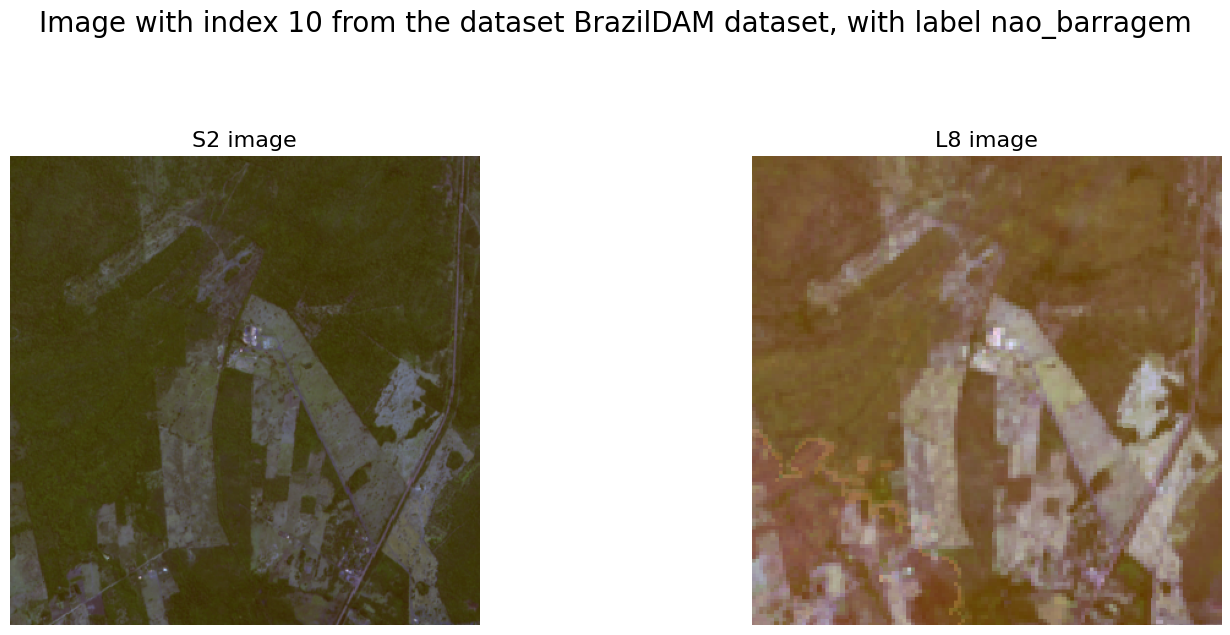

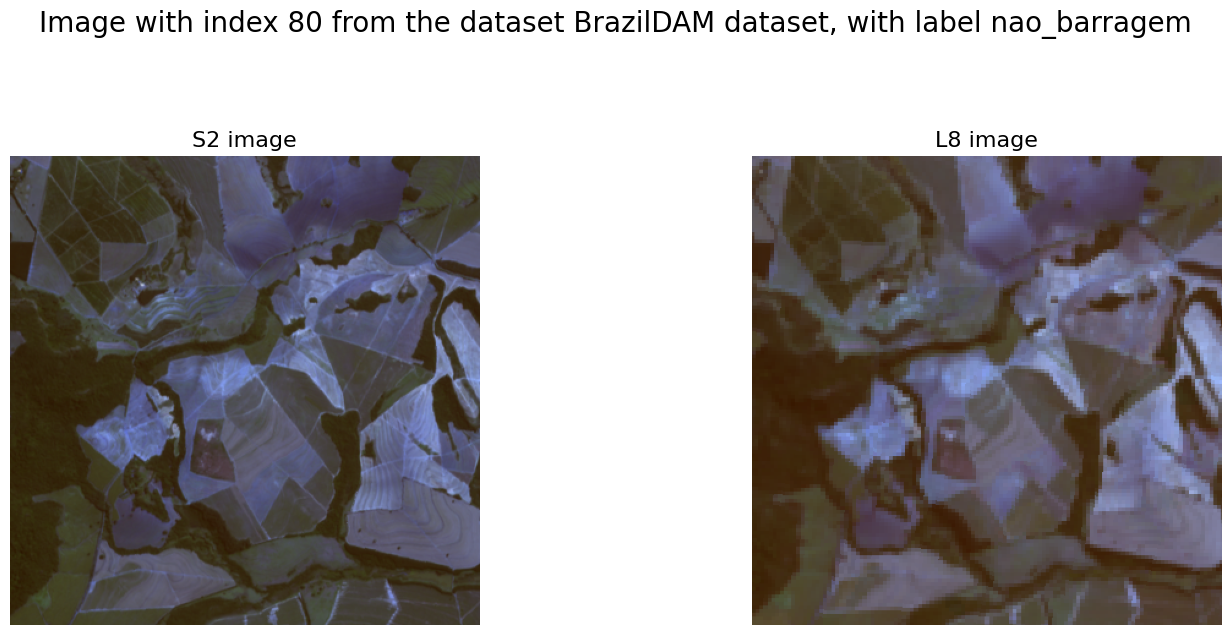

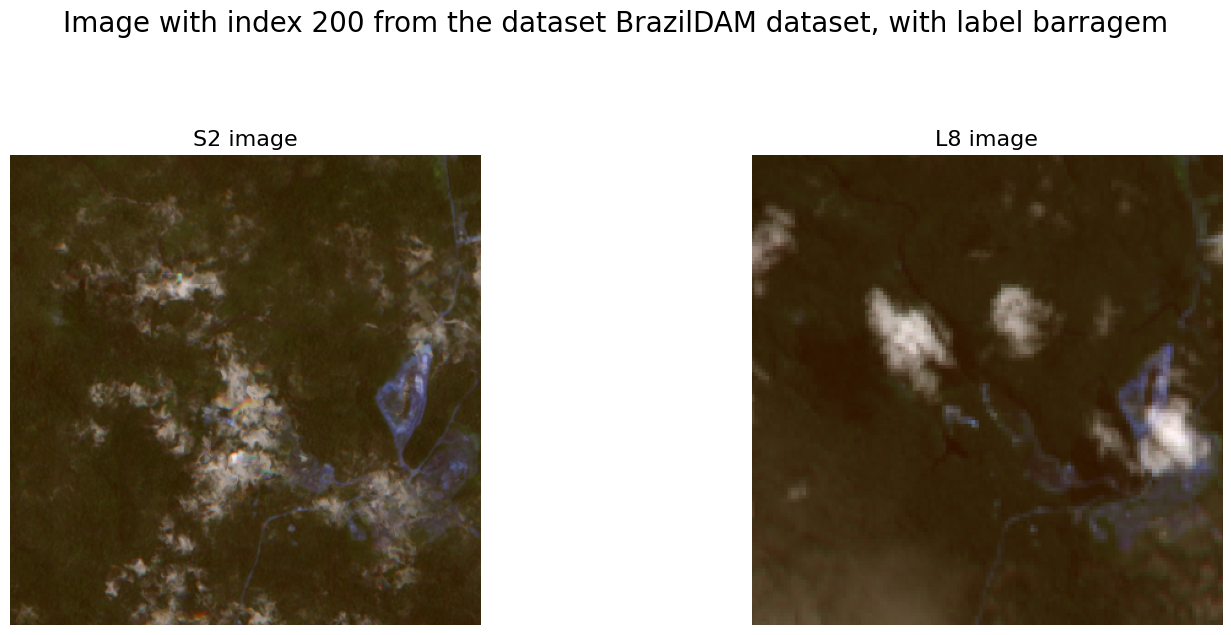

In [5]:
dataset_config = {
    "data_dir": "/home/dragik/data/FAIR_EO/BrazilDAM/",
    "csv_file": "/home/dragik/data/FAIR_EO/BrazilDAM/splits_final/brazildam_train.csv",
    "imagery": "sentinel and landsat paired",
    "selection": "rgb"
}
dataset = BrazilDAMDataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")
fig1 = dataset.show_image(10)
fig2 = dataset.show_image(80)
fig3 = dataset.show_image(200)

## Define train and test datasets

In [6]:
# Train dataset
train_dataset_config = {
    "batch_size": 32,
    "shuffle": True,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/FAIR_EO/BrazilDAM/",
    "csv_file": "/home/dragik/data/FAIR_EO/BrazilDAM/splits_final/brazildam_train.csv",
    "imagery": "sentinel",
    "selection": "bands",
    "bands_s2": ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
    "transforms": ["aitlas.transforms.ResizeRandomCropFlipHVToTensor"]
}
train_dataset = BrazilDAMDataset(train_dataset_config)
print(f"Number of training samples: {len(train_dataset)}")

# Validation dataset
val_dataset_config = {
    "batch_size": 32,
    "shuffle": True,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/FAIR_EO/BrazilDAM/",
    "csv_file": "/home/dragik/data/FAIR_EO/BrazilDAM/splits_final/brazildam_val.csv",
    "imagery": "sentinel",
    "selection": "bands",
    "bands_s2": ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
    "transforms": ["aitlas.transforms.ResizeRandomCropFlipHVToTensor"] 
}
val_dataset = BrazilDAMDataset(val_dataset_config)
print(f"Number of validation samples: {len(val_dataset)}")

# Test dataset
test_dataset_config = {
    "batch_size": 32,
    "shuffle": False,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/FAIR_EO/BrazilDAM/",
    "csv_file": "/home/dragik/data/FAIR_EO/BrazilDAM/splits_final/brazildam_test.csv",
    "imagery": "sentinel",
    "selection": "bands",
    "bands_s2": ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
    "transforms": ["aitlas.transforms.ResizeRandomCropFlipHVToTensor"]
}

test_dataset = BrazilDAMDataset(test_dataset_config)
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 4619
Number of validation samples: 1539
Number of test samples: 1539


## Prepare the model

In [9]:
import torch
from aitlas.base import CompositeModel


# Define the config file
config_data = {
    # Task definition
    "task_type": "multiclass classification",
    "num_classes": 2,
    # Training parameters
    "learning_rate": 0.0001,
    "metrics": ["accuracy", "precision", "recall", "f1_score", "kappa"],
    # Data-model adapter configuration
    "adapter_name": "GalileoAdapter",
    "bands_s2": ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
    # Backbone configuration
    "local_model_path": "tests/checkpoints/encoder.pt",
    "backbone_name": "galileo_nano",
    "pretrained": True,
    "forward_params": {"patch_size": 16},
    # Head configuration
    "head_name": "ScalarHead"
}

print(f"Instantiating CompositeModel with backbone: {config_data['backbone_name']}")

# Instantiate the CompositeModel
model = CompositeModel(config_data)
model.prepare()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Print the architecture
print("\nComposite model architecture created:")
print(f"  Adapter:  {type(model.input_adapter).__name__}")
print(f"  Backbone: {type(model.model.backbone).__name__}")
print(f"  Head:     {type(model.model.head).__name__}")
print(f"\nModel successfully loaded on device: {device}")

Instantiating CompositeModel with backbone: galileo_nano
Provided local model path does not exist: tests/checkpoints/encoder.pt
Weights will be downloaded from Huggingface instead.


2026-05-06 11:47:53,944 INFO HTTP Request: HEAD https://huggingface.co/nasaharvest/galileo/resolve/main/models/nano/encoder.pt "HTTP/1.1 302 Found"
2026-05-06 11:47:53,946 WARNING Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-06 11:47:54,088 INFO HTTP Request: GET https://huggingface.co/api/models/nasaharvest/galileo/xet-read-token/f039dd5dde966a931baeda47eb680fa89b253e4e "HTTP/1.1 200 OK"
2026-05-06 11:47:55,653 INFO HTTP Request: HEAD https://huggingface.co/nasaharvest/galileo/resolve/main/models/nano/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-06 11:47:55,668 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/nasaharvest/galileo/f039dd5dde966a931baeda47eb680fa89b253e4e/models%2Fnano%2Fconfig.json "HTTP/1.1 200 OK"
2026-05-06 11:47:55,683 INFO HTTP Request: GET https://huggingface.co/api/resolve-cache/models/nasaharvest/galileo/f039dd5dde966a931baeda47eb6

Successfully loaded checkpoint: encoder.pt

Composite model architecture created:
  Adapter:  GalileoAdapter
  Backbone: Galileo
  Head:     ScalarHead

Model successfully loaded on device: cuda:0


## Train and evaluate the model

In [ ]:
epochs = 10
model_directory = "/home/dragik/data/FAIR_EO/experiments/BrazilDAM/"

model.train_and_evaluate_model(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    epochs=epochs,
    model_directory=model_directory,
    run_id='1'
);

2026-05-06 11:49:01,057 INFO Starting training.
training:  90%|█████████ | 131/145 [00:33<00:02,  5.13it/s]

## Make predictions

In [ ]:
from aitlas.transforms import ResizeCenterCropToTensor

# Load the model
model_path = "/home/dragik/data/FAIR_EO/experiments/BrazilDAM/checkpoint.pth.tar"
device = torch.device("cuda:0")
model.device = device
model.load_model(model_path)

# Define the labels and transformation
labels = BrazilDAMDataset.labels
transform = ResizeCenterCropToTensor()

# Predict on a test image
image = test_dataset[50][0]
fig = model.predict_image(image, labels, transform)